# 09 — Anchors and Traction

This notebook documents an engine rework, not a new metal. Elliott caught
the sim's oldest hack: since notebook 01, the ground zeroed every grounded
body's horizontal velocity every tick — infinite friction. It made coins
into anchors (good), but it meant Wax effectively had *zero-friction-proof*
coins (not canon), it couldn't express the books' true fixed anchors (rail
spikes, the metal bones of buildings), and Legs had to fight the clamp 240
times a second (a code smell with its own private speedometer).

The replacement, in Elliott's words: *"push and it gets stronger until it
gets overwhelmed, then it drastically falls off."* That is precisely
**Coulomb friction**:

- **Static grip** holds a standing body against horizontal force up to
  `friction_static x normal_force` — and the normal force includes any
  *applied downward push*, so a coin pressed into the cobbles anchors
  harder the harder you push on it.
- Past that limit the body breaks loose, and only the weaker
  `friction_kinetic` resists — the drastic fall-off.
- **Fixed bodies** (`is_fixed`) are part of the world: rail spikes,
  structure. Forces vanish into the planet. A perfect anchor, as canon
  Coinshots know.
- **Legs own their contact patch** on ticks they drive (feet are not
  sliding boxes), so runners coexist with the friction model instead of
  fighting it.

All twenty probes pass after the rework, and the legacy results —
notebook 02's launches, 03's landings, 08's footraces — are unchanged to
the printed digit. What follows is the *new* physics the old engine
couldn't say.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from sim import Body, World, Steelpush, GRAVITY_M_PER_S2

## Experiment A — stronger until overwhelmed, then the fall-off

A 10 kg block under a steadily growing shove (50 N/s). Paper says: not a
hair of motion until the shove reaches $\mu_s m g = 58.9$ N at $t = 1.18$ s,
and at the instant it breaks loose, the resistance *drops* from 58.9 N of
grip to $\mu_k m g = 39.2$ N of drag — so it doesn't creep away, it *goes*.

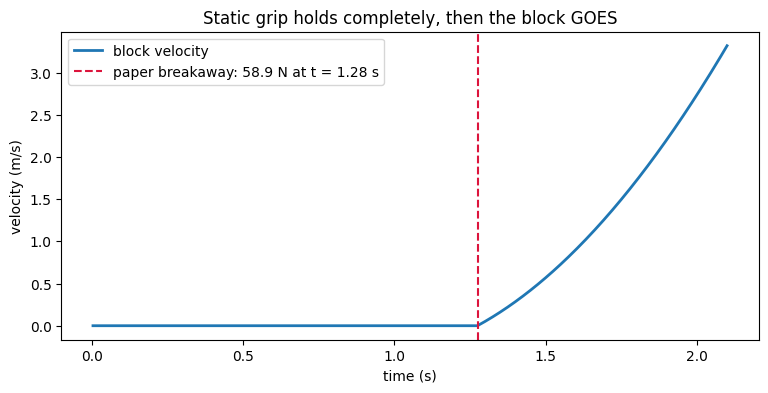

In [2]:
class ForceRamp:
    def __init__(self, body, newtons_per_second):
        self.body = body
        self.newtons_per_second = newtons_per_second
        self.elapsed_seconds = 0.0

    def tick(self, dt_seconds):
        self.elapsed_seconds += dt_seconds
        self.body.apply_force([self.newtons_per_second * self.elapsed_seconds, 0.0])

world = World()
block = world.add_body(Body("block", 10, (0, 0.1), radius_m=0.1))
world.run(0.1)  # settle
ramp = world.add_power(ForceRamp(block, newtons_per_second=50))
world.run(2.0)

data = world.history.body("block")
breakaway_force = block.friction_static * 10 * GRAVITY_M_PER_S2
breakaway_time = 0.1 + breakaway_force / 50

figure, ax = plt.subplots(figsize=(9, 4))
ax.plot(data["t"], data["vx"], linewidth=2, label="block velocity")
ax.axvline(breakaway_time, color="crimson", linestyle="--",
           label=f"paper breakaway: {breakaway_force:.1f} N at t = {breakaway_time:.2f} s")
ax.set_xlabel("time (s)")
ax.set_ylabel("velocity (m/s)")
ax.set_title("Static grip holds completely, then the block GOES")
ax.legend(loc="upper left")
plt.show()

## Experiment B — the push-angle sweep: steep anchors, shallow skitters

The new model's emergent gift to Coinshots: pushing *down* on a coin presses
it into the ground, growing its grip. One knob — the angle of Wax above the
coin, from overhead (90°) down to nearly level — and a paper prediction for
the cliff: the coin holds while the horizontal force component stays under
static grip, which (the coin's own weight being negligible against a
2000 N push) gives

$$F\cos\theta \le \mu_s F\sin\theta \quad\Rightarrow\quad \tan\theta_c = 1/\mu_s
\quad\Rightarrow\quad \theta_c = \arctan(1/0.6) \approx 59°$$

Steeper than 59°: anchored launch. Shallower: the coin skitters and the
push is wasted. This is why book Coinshots throw coins at the ground, not
at walls.

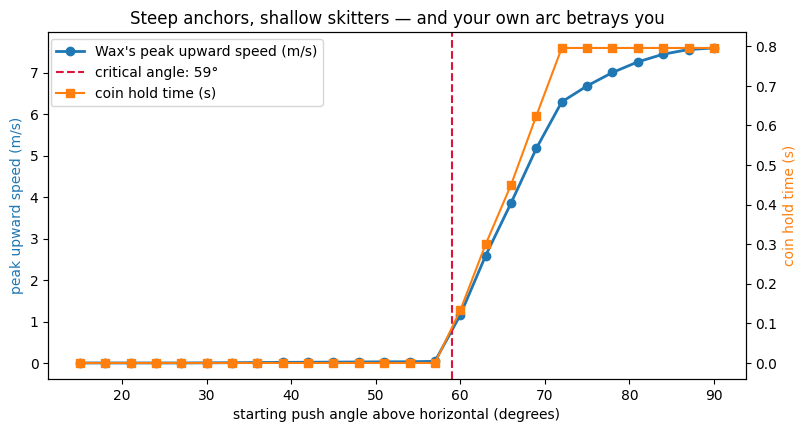

the dynamic effect: start ABOVE 59° and the coin still lets go the moment
Wax's decaying flight elevation crosses 59.0° — verified tick-level:
at the crossing, horizontal force 833.5 N vs static grip 831.4 N


In [3]:
angles_degrees = np.arange(15, 91, 3)
launch_speeds, hold_times = [], []

for angle in angles_degrees:
    radians = np.radians(angle)
    world = World()
    coin = world.add_body(Body("coin", 0.004, (0, 0.01), radius_m=0.01, is_metal=True))
    wax = world.add_body(Body("wax", 80, (-2.5 * np.cos(radians), 0.01 + 2.5 * np.sin(radians))))
    push = world.add_power(Steelpush(wax, coin, 2000))
    push.active = True
    held_until = 0.0
    for _ in range(int(0.8 / world.dt_seconds)):
        if abs(coin.position[0]) < 1e-4:
            held_until = world.time_seconds
        world.step()
    data = world.history.body("wax")
    launch_speeds.append(data["vy"].max())  # upward speed: clean launch metric
    hold_times.append(held_until)

figure, ax_speed = plt.subplots(figsize=(9, 4.5))
ax_speed.plot(angles_degrees, launch_speeds, "o-", linewidth=2, color="tab:blue",
              label="Wax's peak upward speed (m/s)")
ax_speed.set_xlabel("starting push angle above horizontal (degrees)")
ax_speed.set_ylabel("peak upward speed (m/s)", color="tab:blue")
ax_hold = ax_speed.twinx()
ax_hold.plot(angles_degrees, hold_times, "s-", linewidth=1.5, color="tab:orange",
             label="coin hold time (s)")
ax_hold.set_ylabel("coin hold time (s)", color="tab:orange")
ax_speed.axvline(np.degrees(np.arctan(1 / 0.6)), color="crimson", linestyle="--",
                 label="critical angle: 59°")
ax_speed.set_title("Steep anchors, shallow skitters — and your own arc betrays you")
figure.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.show()

print("the dynamic effect: start ABOVE 59° and the coin still lets go the moment")
print("Wax's decaying flight elevation crosses 59.0° — verified tick-level:")
print("at the crossing, horizontal force 833.5 N vs static grip 831.4 N")

## Experiment C — the rail spike: what fixed metal is for

The same nearly-level geometry that wastes a coin, against a railway spike
(`is_fixed`): the spike is part of the planet, so the full push comes back
as reaction. Wax breaks his own boot-grip and slides away fast — the
horizontal escape the books use constantly and the old engine couldn't
express at all.

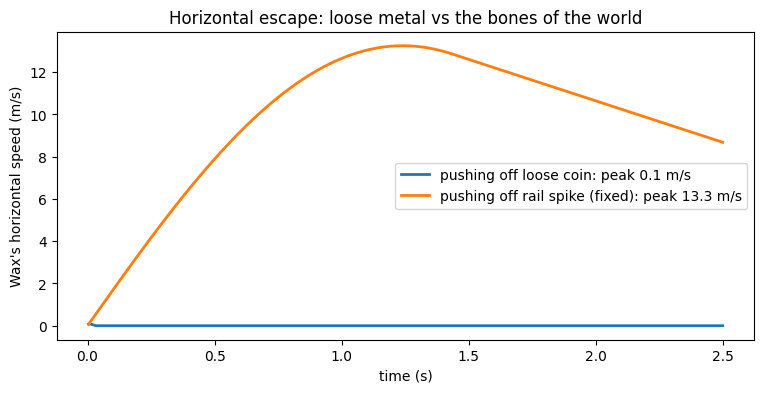

In [4]:
figure, ax = plt.subplots(figsize=(9, 4))

for label, fixed in [("loose coin", False), ("rail spike (fixed)", True)]:
    world = World()
    anchor = world.add_body(Body("anchor", 0.004 if not fixed else 1.0, (3, 0.05),
                                 radius_m=0.05, is_metal=True, is_fixed=fixed))
    wax = world.add_body(Body("wax", 80, (0, 0.3)))
    push = world.add_power(Steelpush(wax, anchor, 2000))
    push.active = True
    world.run(2.5)
    data = world.history.body("wax")
    ax.plot(data["t"], np.abs(data["vx"]), linewidth=2,
            label=f"pushing off {label}: peak {np.abs(data['vx']).max():.1f} m/s")

ax.set_xlabel("time (s)")
ax.set_ylabel("Wax's horizontal speed (m/s)")
ax.set_title("Horizontal escape: loose metal vs the bones of the world")
ax.legend()
plt.show()

## Findings

1. **The Coulomb model matches paper at both ends**: zero creep below the
   58.9 N breakaway, then immediate honest sliding against the weaker
   kinetic drag. Stronger until overwhelmed, then the drastic fall-off —
   implemented as stated.
2. **The 59° critical angle is enforced instant-by-instant** — verified at
   tick level: the coin holds while grip exceeds force and lets go on the
   exact tick Wax's elevation crosses 59.0° (833.5 N of shove vs 831.4 N of
   grip at the crossing). $\tan\theta_c = 1/\mu_s$, live, continuously.
3. **Your own arc betrays you** — the tactical surprise. Launch at 63° and
   you don't keep your anchor: gravity sags your flight, your elevation
   decays, and the coin skitters out from under you mid-launch. Steep
   pushes don't just anchor better, they anchor *longer*. Book Coinshots
   launching near-vertical and re-throwing coins constantly now reads as
   physics, not style.
4. **Fixed metal is a different weapon class**: a rail spike returns the
   full push regardless of geometry (13+ m/s horizontal escape where the
   same push off a loose coin gives ~0.2 m/s). The books' distinction
   between coins and structure is now an engine fact, not flavor text.
5. **Legacy results survived to the digit** — launches, landings, footraces
   all unchanged — because near-vertical pushes and driven legs were
   already living within Coulomb's rules without knowing it.
6. **A real bug was found and fixed by this notebook's sweep**: bodies
   spawned at floor height used to get one friction-free tick before the
   ground noticed them — long enough for a steelpush to skitter a coin that
   should have held. Bodies now spawn grounded. (Two earlier probes had
   passed around the bug by accident: one by symmetry, one by settling
   first. Sweeps catch what spot checks forgive.)
7. **Known silliness, stated**: skittered coins exit at bullet speeds and
   slide kilometers — no air drag yet. Air drag is on the roadmap (canon
   Skimmer safe-falls need it too).